In [1]:
import ee
ee.Authenticate()


C:\Users\Akshay\anaconda3\envs\emission_project\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [8]:
import ee
ee.Initialize(project='emissionproject1')
print("✅ Ready")

✅ Ready


In [9]:
import ee
ee.Initialize(project='emissionproject1')


CALCULATING NDVI

In [11]:
# Location (Bhopal example)
point = ee.Geometry.Point([77.4126, 23.2599])

# Get Sentinel-2 data
image = (
    ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
    .filterBounds(point)
    .filterDate("2024-01-01", "2024-01-31")
    .median()
)

# NDVI calculation
ndvi = image.normalizedDifference(['B8', 'B4'])

# Extract value
ndvi_value = ndvi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=point,
    scale=10
)

print("NDVI:", ndvi_value.getInfo())

NDVI: {'nd': 0.24860388985172346}


TIME SERIES


In [16]:
import ee
import pandas as pd

ee.Initialize(project='emissionproject1')

# Location
point = ee.Geometry.Point([77.4126, 23.2599])

# Date range
start_date = "2023-01-01"
end_date = "2024-01-01"

# Load collection
collection = (
    ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
    .filterBounds(point)
    .filterDate(start_date, end_date)
)

# Function to calculate NDVI for each image
def get_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    
    value = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=10
    )
    
    return ee.Feature(None, {
        'date': image.date().format(),
        'ndvi': value.get('NDVI')
    })

# Apply function
ndvi_series = collection.map(get_ndvi)

# Convert to list
ndvi_list = ndvi_series.getInfo()['features']

# Convert to pandas
data = []
for item in ndvi_list:
    props = item['properties']
    data.append({
        'date': props['date'],
        'ndvi': props['ndvi']
    })

df = pd.DataFrame(data)

df

,date,ndvi
0,2023-01-01T05:32:33,0.239085
1,2023-01-06T05:32:34,0.254268
2,2023-01-11T05:32:31,0.294472
3,2023-01-16T05:32:31,0.212121
4,2023-01-21T05:32:32,0.123973
...,...,...
68,2023-12-07T05:32:31,0.002494
69,2023-12-12T05:32:30,0.294639
70,2023-12-17T05:32:34,0.212988
71,2023-12-22T05:32:31,0.282959


VISUALIZE TRENDS

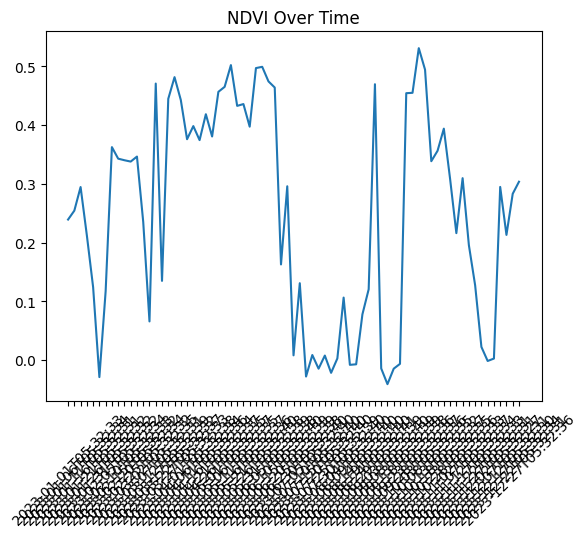

In [17]:
import matplotlib.pyplot as plt

plt.plot(df['date'], df['ndvi'])
plt.xticks(rotation=45)
plt.title("NDVI Over Time")
plt.show()

CLEANING DATA

In [20]:
df = df.dropna()  # remove None values
df['date'] = pd.to_datetime(df['date'])  # convert to date format
df = df.sort_values('date')  # sort by time

df.reset_index(drop=True, inplace=True)

df


,date,ndvi
0,2023-01-01 05:32:33,0.239085
1,2023-01-06 05:32:34,0.254268
2,2023-01-11 05:32:31,0.294472
3,2023-01-16 05:32:31,0.212121
4,2023-01-21 05:32:32,0.123973
...,...,...
68,2023-12-07 05:32:31,0.002494
69,2023-12-12 05:32:30,0.294639
70,2023-12-17 05:32:34,0.212988
71,2023-12-22 05:32:31,0.282959


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    73 non-null     datetime64[ns]
 1   ndvi    73 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.3 KB


FETCH WEATHER DATA

In [27]:
import requests

API_KEY = "16d8843fd2bfdf111cbbcdecab7b5b9e"

lat = 23.2599
lon = 77.4126

url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}"

data = requests.get(url).json()

temp = data['main']['temp']
humidity = data['main']['humidity']

print("Temp:", temp)
print("Humidity:", humidity)
temp_c = 308.33 - 273.15
print(temp_c)

Temp: 308.33
Humidity: 9
35.18000000000001


In [30]:
import requests
import pandas as pd

lat = 23.2599
lon = 77.4126

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date=2023-01-01&end_date=2024-01-01&daily=temperature_2m_max,temperature_2m_min,precipitation_sum"

data = requests.get(url).json()

weather_df = pd.DataFrame({
    'date': data['daily']['time'],
    'temp_max': data['daily']['temperature_2m_max'],
    'temp_min': data['daily']['temperature_2m_min'],
    'rainfall': data['daily']['precipitation_sum']
})

weather_df['date'] = pd.to_datetime(weather_df['date'])

weather_df


,date,temp_max,temp_min,rainfall
0,2023-01-01,21.8,10.1,0.0
1,2023-01-02,21.4,9.1,0.0
2,2023-01-03,20.7,8.6,0.0
3,2023-01-04,19.0,7.9,0.0
4,2023-01-05,19.6,7.6,0.0
...,...,...,...,...
361,2023-12-28,25.0,12.1,0.0
362,2023-12-29,25.5,12.0,0.0
363,2023-12-30,26.1,12.6,0.0
364,2023-12-31,26.7,14.0,0.0


In [32]:
# Merge using nearest date
final_df = pd.merge_asof(
    df.sort_values('date'),
    weather_df.sort_values('date'),
    on='date',
    direction='nearest'
)

final_df

,date,ndvi,temp_max,temp_min,rainfall
0,2023-01-01 05:32:33,0.239085,21.8,10.1,0.0
1,2023-01-06 05:32:34,0.254268,21.5,7.4,0.0
2,2023-01-11 05:32:31,0.294472,24.8,9.6,0.0
3,2023-01-16 05:32:31,0.212121,21.7,7.1,0.0
4,2023-01-21 05:32:32,0.123973,26.5,12.9,0.1
...,...,...,...,...,...
68,2023-12-07 05:32:31,0.002494,22.8,14.6,0.1
69,2023-12-12 05:32:30,0.294639,24.5,12.8,0.0
70,2023-12-17 05:32:34,0.212988,23.1,11.1,0.0
71,2023-12-22 05:32:31,0.282959,22.0,11.8,0.0


In [34]:
final_df.to_csv("data/final_dataset.csv", index=False)

In [35]:
from sklearn.model_selection import train_test_split

# Features
X = final_df[['temp_max', 'temp_min', 'rainfall']]

# Target
y = final_df['ndvi']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.006114645663717063


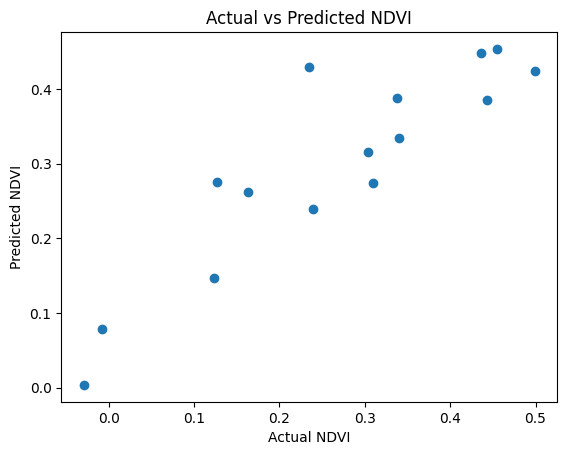

In [41]:
import matplotlib.pyplot as plt
final_df['month'] = final_df['date'].dt.month
final_df['day'] = final_df['date'].dt.day
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Actual vs Predicted NDVI")
plt.show()